# DFU Binary Classification — EfficientNet-B0
**Úlcera diabética de pie vs. Piel sana**

Dataset esperado en Google Drive:
```
MyDrive/DFU/
├── Patches/
│   ├── Abnormal(Ulcer)/
│   └── Normal(Healthy skin)/
└── TestSet/          ← imágenes sin etiqueta → se exportan predicciones
```

In [1]:
import os
for carpeta in ['Abnormal(Ulcer)', 'Normal(Healthy skin)']:
    ruta = f'/content/drive/MyDrive/DFU/Patches/{carpeta}'
    archivos = os.listdir(ruta)
    print(f'{carpeta}: {len(archivos)} archivos')

Abnormal(Ulcer): 485 archivos
Normal(Healthy skin): 875 archivos


In [2]:
# ── 0. Instalar dependencias ──────────────────────────────────────────────────
!pip install -q timm scikit-learn matplotlib seaborn grad-cam onnxruntime

In [3]:
# ── 1. Montar Google Drive ────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os
print(os.listdir('/content/drive/MyDrive/DFU/Patches'))

['Abnormal(Ulcer)', 'Normal(Healthy skin)']


In [5]:
# ── 2. Configuración global ───────────────────────────────────────────────────
import os

BASE_DIR    = '/content/drive/MyDrive/DFU'
PATCHES_DIR = os.path.join(BASE_DIR, 'Patches')
TEST_DIR    = os.path.join(BASE_DIR, 'TestSet')

IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_EPOCHS  = 30
LR          = 1e-4
LR_BACKBONE = 1e-5
VAL_SPLIT   = 0.2
SEED        = 42
NUM_WORKERS = 2
PATIENCE    = 6

CLASSES = ['Normal(Healthy skin)', 'Abnormal(Ulcer)']

import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando: {DEVICE}')

Usando: cuda


In [6]:
# ── 3. Imports ────────────────────────────────────────────────────────────────
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(SEED)

In [7]:
# ── 4. Transforms ─────────────────────────────────────────────────────────────
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

In [8]:
# ── 5. Dataset y DataLoaders ──────────────────────────────────────────────────
full_dataset = datasets.ImageFolder(PATCHES_DIR)
original_class_to_idx = full_dataset.class_to_idx
print('Clases detectadas:', original_class_to_idx)

remap = {}
for cls_name, idx in original_class_to_idx.items():
    remap[idx] = 1 if 'Abnormal' in cls_name else 0
print('Remap de etiquetas:', remap)

targets = [full_dataset.targets[i] for i in range(len(full_dataset))]
train_idx, val_idx = train_test_split(
    range(len(full_dataset)),
    test_size=VAL_SPLIT,
    stratify=targets,
    random_state=SEED
)

train_base = Subset(full_dataset, train_idx)
val_base   = Subset(full_dataset, val_idx)

class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform, remap):
        self.subset    = subset
        self.transform = transform
        self.remap     = remap

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        return self.transform(img), self.remap[label]

full_dataset.transform = None

train_ds = TransformSubset(train_base, train_tf, remap)
val_ds   = TransformSubset(val_base,   val_tf,   remap)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train: {len(train_ds)} imágenes | Val: {len(val_ds)} imágenes')

train_labels = [remap[targets[i]] for i in train_idx]
print(f'Train — Normal: {train_labels.count(0)} | Ulcer: {train_labels.count(1)}')

Clases detectadas: {'Abnormal(Ulcer)': 0, 'Normal(Healthy skin)': 1}
Remap de etiquetas: {0: 1, 1: 0}
Train: 1088 imágenes | Val: 272 imágenes
Train — Normal: 700 | Ulcer: 388


In [9]:
# ── 6. Modelo EfficientNet-B0 ─────────────────────────────────────────────────
def build_model(num_classes=2, freeze_backbone=True):
    model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=num_classes)
    if freeze_backbone:
        for name, param in model.named_parameters():
            if 'classifier' not in name:
                param.requires_grad = False
    return model

model = build_model(num_classes=2, freeze_backbone=True).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Parámetros entrenables: {trainable:,} / {total:,}')

model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

Parámetros entrenables: 2,562 / 4,010,110


In [10]:
# ── 7. Loss con peso por clase ────────────────────────────────────────────────
n_normal = train_labels.count(0)
n_ulcer  = train_labels.count(1)
weight   = torch.tensor([n_ulcer / n_normal, 1.0], dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weight)
print(f'Pesos de clase: Normal={weight[0]:.3f}, Ulcer={weight[1]:.3f}')

Pesos de clase: Normal=0.554, Ulcer=1.000


In [11]:
# ── 8. Loop de entrenamiento ──────────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += len(labels)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        loss   = criterion(logits, labels)
        probs  = torch.softmax(logits, dim=1)[:, 1]
        total_loss += loss.item() * len(labels)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += len(labels)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / total
    acc      = correct / total
    auc      = roc_auc_score(all_labels, all_probs)
    return avg_loss, acc, auc, np.array(all_labels), np.array(all_probs)

In [12]:
# ── 9. Fase 1: backbone congelado ─────────────────────────────────────────────
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-4
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_auc': []}
best_auc   = 0.0
patience_c = 0
PHASE1_EPOCHS = 10

print('=== Fase 1: backbone congelado ===')
for epoch in range(1, PHASE1_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    vl_loss, vl_acc, vl_auc, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['val_auc'].append(vl_auc)

    if vl_auc > best_auc:
        best_auc = vl_auc
        torch.save(model.state_dict(), '/content/best_model.pth')
        patience_c = 0
    else:
        patience_c += 1

    print(f'Epoch {epoch:02d} | '
          f'Loss {tr_loss:.4f}/{vl_loss:.4f} | '
          f'Acc {tr_acc:.3f}/{vl_acc:.3f} | '
          f'AUC {vl_auc:.4f} {"★" if patience_c == 0 else ""}')

=== Fase 1: backbone congelado ===
Epoch 01 | Loss 2.2478/2.5435 | Acc 0.563/0.489 | AUC 0.5078 ★
Epoch 02 | Loss 1.9795/2.3480 | Acc 0.587/0.518 | AUC 0.5443 ★
Epoch 03 | Loss 1.9803/2.4083 | Acc 0.578/0.500 | AUC 0.5481 ★
Epoch 04 | Loss 1.7132/2.2675 | Acc 0.610/0.515 | AUC 0.5694 ★
Epoch 05 | Loss 1.8361/2.1380 | Acc 0.600/0.518 | AUC 0.5895 ★
Epoch 06 | Loss 1.7722/2.1956 | Acc 0.606/0.559 | AUC 0.5870 
Epoch 07 | Loss 1.6948/2.0931 | Acc 0.608/0.533 | AUC 0.6017 ★
Epoch 08 | Loss 1.6621/2.1297 | Acc 0.618/0.544 | AUC 0.5984 
Epoch 09 | Loss 1.6423/2.0463 | Acc 0.592/0.548 | AUC 0.6042 ★
Epoch 10 | Loss 1.6874/2.0385 | Acc 0.625/0.559 | AUC 0.6108 ★


In [13]:
# ── 10. Fase 2: fine-tuning completo ─────────────────────────────────────────
print('\n=== Fase 2: fine-tuning completo ===')

for param in model.parameters():
    param.requires_grad = True

backbone_params   = [p for n, p in model.named_parameters() if 'classifier' not in n]
classifier_params = [p for n, p in model.named_parameters() if 'classifier' in n]

optimizer = optim.AdamW([
    {'params': backbone_params,   'lr': LR_BACKBONE},
    {'params': classifier_params, 'lr': LR},
], weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS - PHASE1_EPOCHS)

patience_c = 0

for epoch in range(PHASE1_EPOCHS + 1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    vl_loss, vl_acc, vl_auc, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['val_auc'].append(vl_auc)

    if vl_auc > best_auc:
        best_auc = vl_auc
        torch.save(model.state_dict(), '/content/best_model.pth')
        patience_c = 0
    else:
        patience_c += 1

    print(f'Epoch {epoch:02d} | '
          f'Loss {tr_loss:.4f}/{vl_loss:.4f} | '
          f'Acc {tr_acc:.3f}/{vl_acc:.3f} | '
          f'AUC {vl_auc:.4f} {"★" if patience_c == 0 else ""}')

    if patience_c >= PATIENCE:
        print(f'Early stopping en epoch {epoch}')
        break

print(f'\nMejor AUC en val: {best_auc:.4f}')


=== Fase 2: fine-tuning completo ===
Epoch 11 | Loss 1.0050/1.0692 | Acc 0.731/0.732 | AUC 0.8412 ★
Epoch 12 | Loss 0.5500/0.6762 | Acc 0.845/0.812 | AUC 0.9190 ★
Epoch 13 | Loss 0.3333/0.6135 | Acc 0.891/0.820 | AUC 0.9312 ★
Epoch 14 | Loss 0.3112/0.4665 | Acc 0.904/0.868 | AUC 0.9552 ★
Epoch 15 | Loss 0.3225/0.3951 | Acc 0.920/0.890 | AUC 0.9635 ★
Epoch 16 | Loss 0.2631/0.3895 | Acc 0.929/0.897 | AUC 0.9689 ★
Epoch 17 | Loss 0.2508/0.3117 | Acc 0.938/0.919 | AUC 0.9763 ★
Epoch 18 | Loss 0.1220/0.2650 | Acc 0.956/0.941 | AUC 0.9799 ★
Epoch 19 | Loss 0.1066/0.2858 | Acc 0.956/0.923 | AUC 0.9798 
Epoch 20 | Loss 0.1629/0.2714 | Acc 0.957/0.934 | AUC 0.9798 
Epoch 21 | Loss 0.1558/0.2510 | Acc 0.950/0.941 | AUC 0.9817 ★
Epoch 22 | Loss 0.1373/0.2595 | Acc 0.958/0.941 | AUC 0.9839 ★
Epoch 23 | Loss 0.1493/0.2552 | Acc 0.965/0.941 | AUC 0.9811 
Epoch 24 | Loss 0.1336/0.2416 | Acc 0.964/0.941 | AUC 0.9829 
Epoch 25 | Loss 0.1748/0.2398 | Acc 0.949/0.930 | AUC 0.9858 ★
Epoch 26 | Loss 0.141

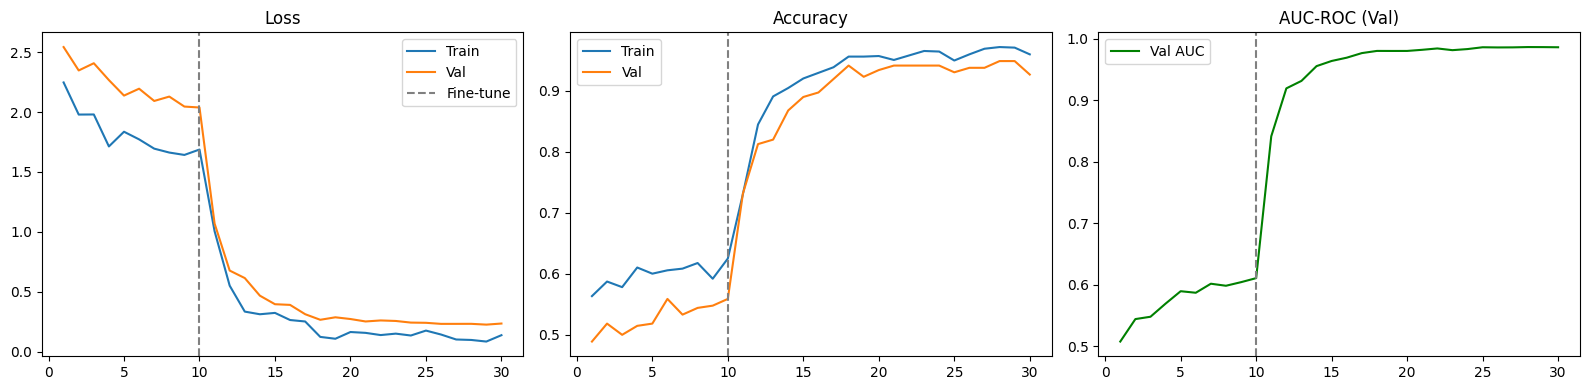

In [14]:
# ── 11. Curvas de entrenamiento ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
epochs_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_range, history['train_loss'], label='Train')
axes[0].plot(epochs_range, history['val_loss'],   label='Val')
axes[0].axvline(PHASE1_EPOCHS, color='gray', linestyle='--', label='Fine-tune')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(epochs_range, history['train_acc'], label='Train')
axes[1].plot(epochs_range, history['val_acc'],   label='Val')
axes[1].axvline(PHASE1_EPOCHS, color='gray', linestyle='--')
axes[1].set_title('Accuracy'); axes[1].legend()

axes[2].plot(epochs_range, history['val_auc'], color='green', label='Val AUC')
axes[2].axvline(PHASE1_EPOCHS, color='gray', linestyle='--')
axes[2].set_title('AUC-ROC (Val)'); axes[2].legend()

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()

=== Métricas en validación (mejor modelo) ===
Accuracy : 0.9485
AUC-ROC  : 0.9861
F1-score : 0.9307

              precision    recall  f1-score   support

      Normal       0.98      0.94      0.96       175
       Ulcer       0.90      0.97      0.93        97

    accuracy                           0.95       272
   macro avg       0.94      0.95      0.94       272
weighted avg       0.95      0.95      0.95       272



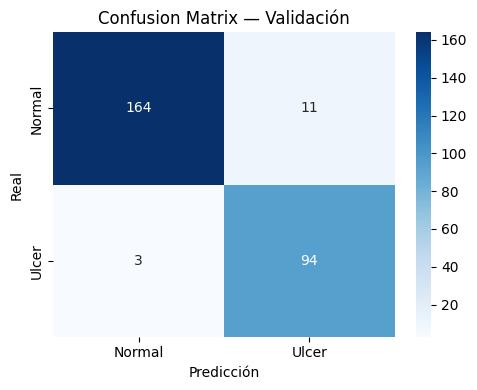

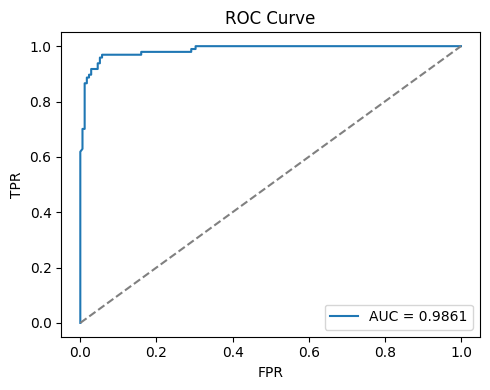

In [15]:
# ── 12. Evaluación final en validación ───────────────────────────────────────
model.load_state_dict(torch.load('/content/best_model.pth'))

_, val_acc, val_auc, y_true, y_prob = evaluate(model, val_loader, criterion, DEVICE)
y_pred = (y_prob >= 0.5).astype(int)

print('=== Métricas en validación (mejor modelo) ===')
print(f'Accuracy : {val_acc:.4f}')
print(f'AUC-ROC  : {val_auc:.4f}')
print(f'F1-score : {f1_score(y_true, y_pred):.4f}')
print()
print(classification_report(y_true, y_pred, target_names=['Normal', 'Ulcer']))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Ulcer'], yticklabels=['Normal', 'Ulcer'])
plt.xlabel('Predicción'); plt.ylabel('Real')
plt.title('Confusion Matrix — Validación')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()

fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f'AUC = {val_auc:.4f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curve'); plt.legend()
plt.tight_layout()
plt.savefig('/content/roc_curve.png', dpi=150)
plt.show()

In [16]:
# ── 13. Inferencia sobre TestSet (sin etiquetas) ──────────────────────────────
VALID_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.gif'}

class UnlabeledDataset(torch.utils.data.Dataset):
    def __init__(self, folder, transform):
        self.paths = sorted([
            p for p in Path(folder).iterdir()
            if p.suffix.lower() in VALID_EXT
        ])
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        try:
            img = Image.open(path).convert('RGB')
        except Exception:
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE))
        return self.transform(img), str(path.name)

test_ds     = UnlabeledDataset(TEST_DIR, val_tf)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS)

model.eval()
results = []
with torch.no_grad():
    for imgs, fnames in test_loader:
        imgs   = imgs.to(DEVICE)
        logits = model(imgs)
        probs  = torch.softmax(logits, dim=1)
        preds  = logits.argmax(1).cpu().numpy()
        for fname, pred, prob in zip(fnames, preds, probs.cpu().numpy()):
            results.append({
                'filename'   : fname,
                'prediction' : 'Ulcer' if pred == 1 else 'Normal',
                'prob_normal': round(float(prob[0]), 4),
                'prob_ulcer' : round(float(prob[1]), 4),
            })

df_pred = pd.DataFrame(results)
df_pred.to_csv('/content/testset_predictions.csv', index=False)
print(f'Predicciones guardadas: {len(df_pred)} imágenes')
print(df_pred['prediction'].value_counts())
df_pred.head(10)

Predicciones guardadas: 167 imágenes
prediction
Ulcer     155
Normal     12
Name: count, dtype: int64


,filename,prediction,prob_normal,prob_ulcer
0,0.jpg,Ulcer,0.0823,0.9177
1,0cbt67mm0fr01.jpg,Ulcer,0.0001,0.9999
2,1 .jpg,Ulcer,0.0000,1.0000
3,1.jpg,Normal,0.5650,0.4350
4,10.jpg,Ulcer,0.3238,0.6762
5,11.jpg,Ulcer,0.0000,1.0000
6,1167 (1).jpg,Ulcer,0.0001,0.9999
7,1167.jpg,Ulcer,0.0000,1.0000
8,12.jpg,Normal,0.7912,0.2088
9,13.jpg,Ulcer,0.0002,0.9998


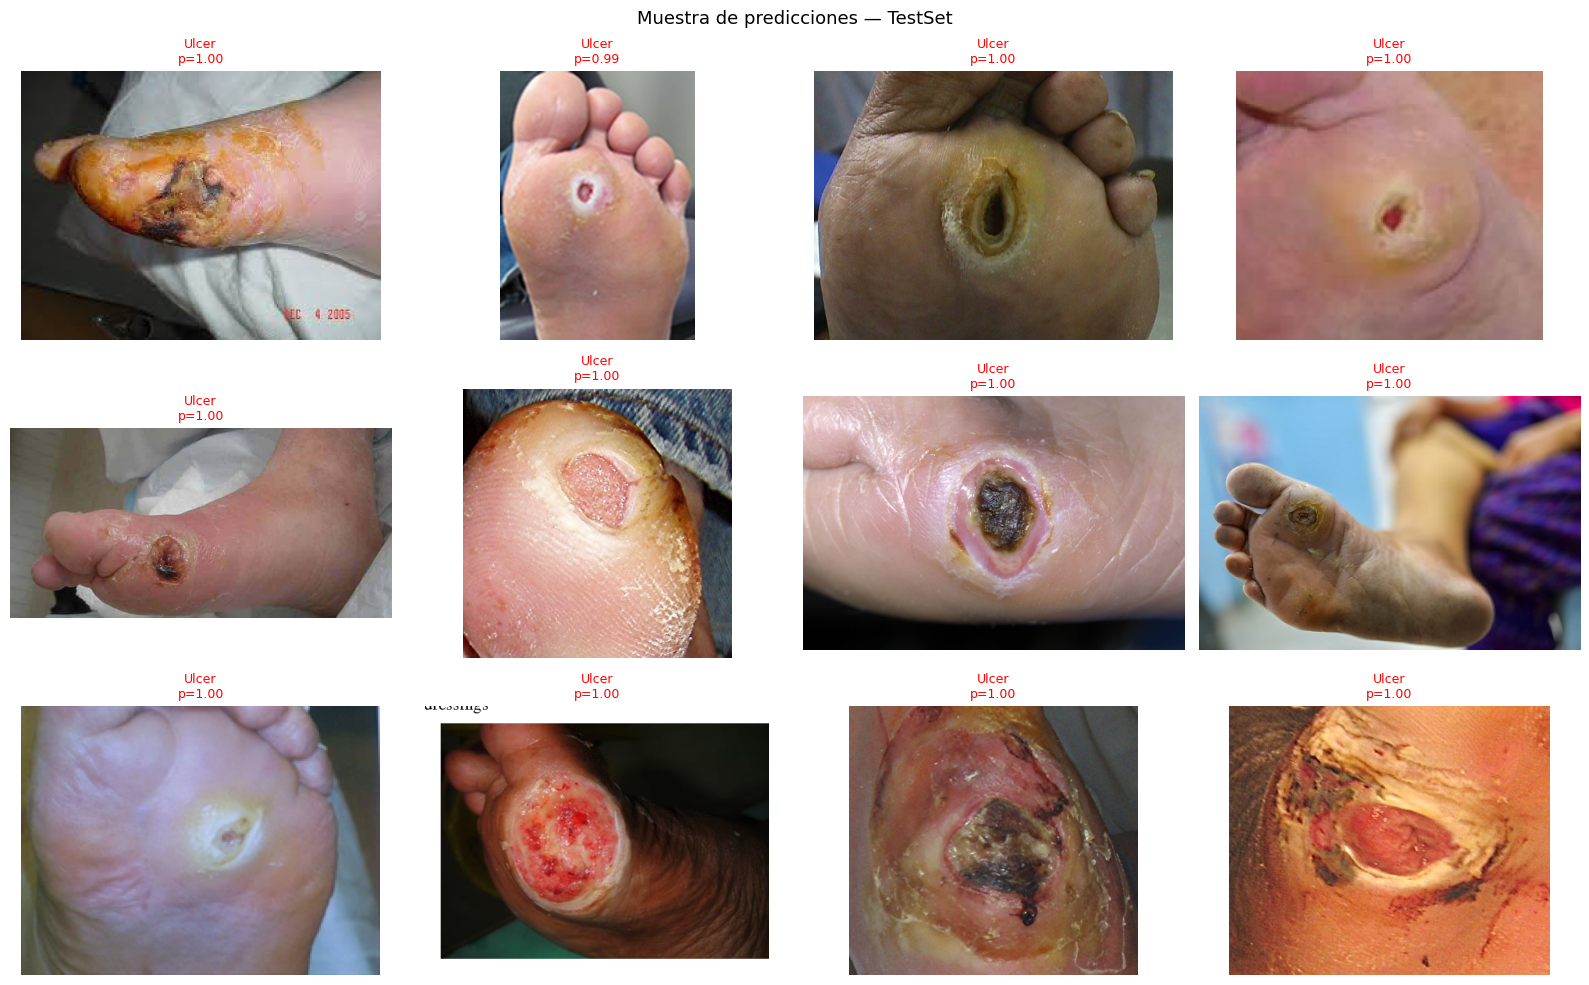

In [17]:
# ── 14. Visualizar predicciones del TestSet ───────────────────────────────────
n_show = 12
sample = df_pred.sample(n=min(n_show, len(df_pred)), random_state=SEED)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):
    img_path = os.path.join(TEST_DIR, row['filename'])
    try:
        img = Image.open(img_path).convert('RGB')
    except Exception:
        img = Image.new('RGB', (224, 224))
    ax.imshow(img)
    color = 'red' if row['prediction'] == 'Ulcer' else 'green'
    ax.set_title(f"{row['prediction']}\np={row['prob_ulcer']:.2f}",
                 color=color, fontsize=9)
    ax.axis('off')

plt.suptitle('Muestra de predicciones — TestSet', fontsize=13)
plt.tight_layout()
plt.savefig('/content/testset_sample.png', dpi=150)
plt.show()

---
## 15 — Grad-CAM: visualización de zonas activadas
Usamos `pytorch-grad-cam` sobre el último bloque MBConv de EfficientNet-B0.
Las zonas cálidas (rojo/amarillo) son las regiones que más pesaron en la decisión del modelo.

In [21]:
!pip install onnxscript onnx -q

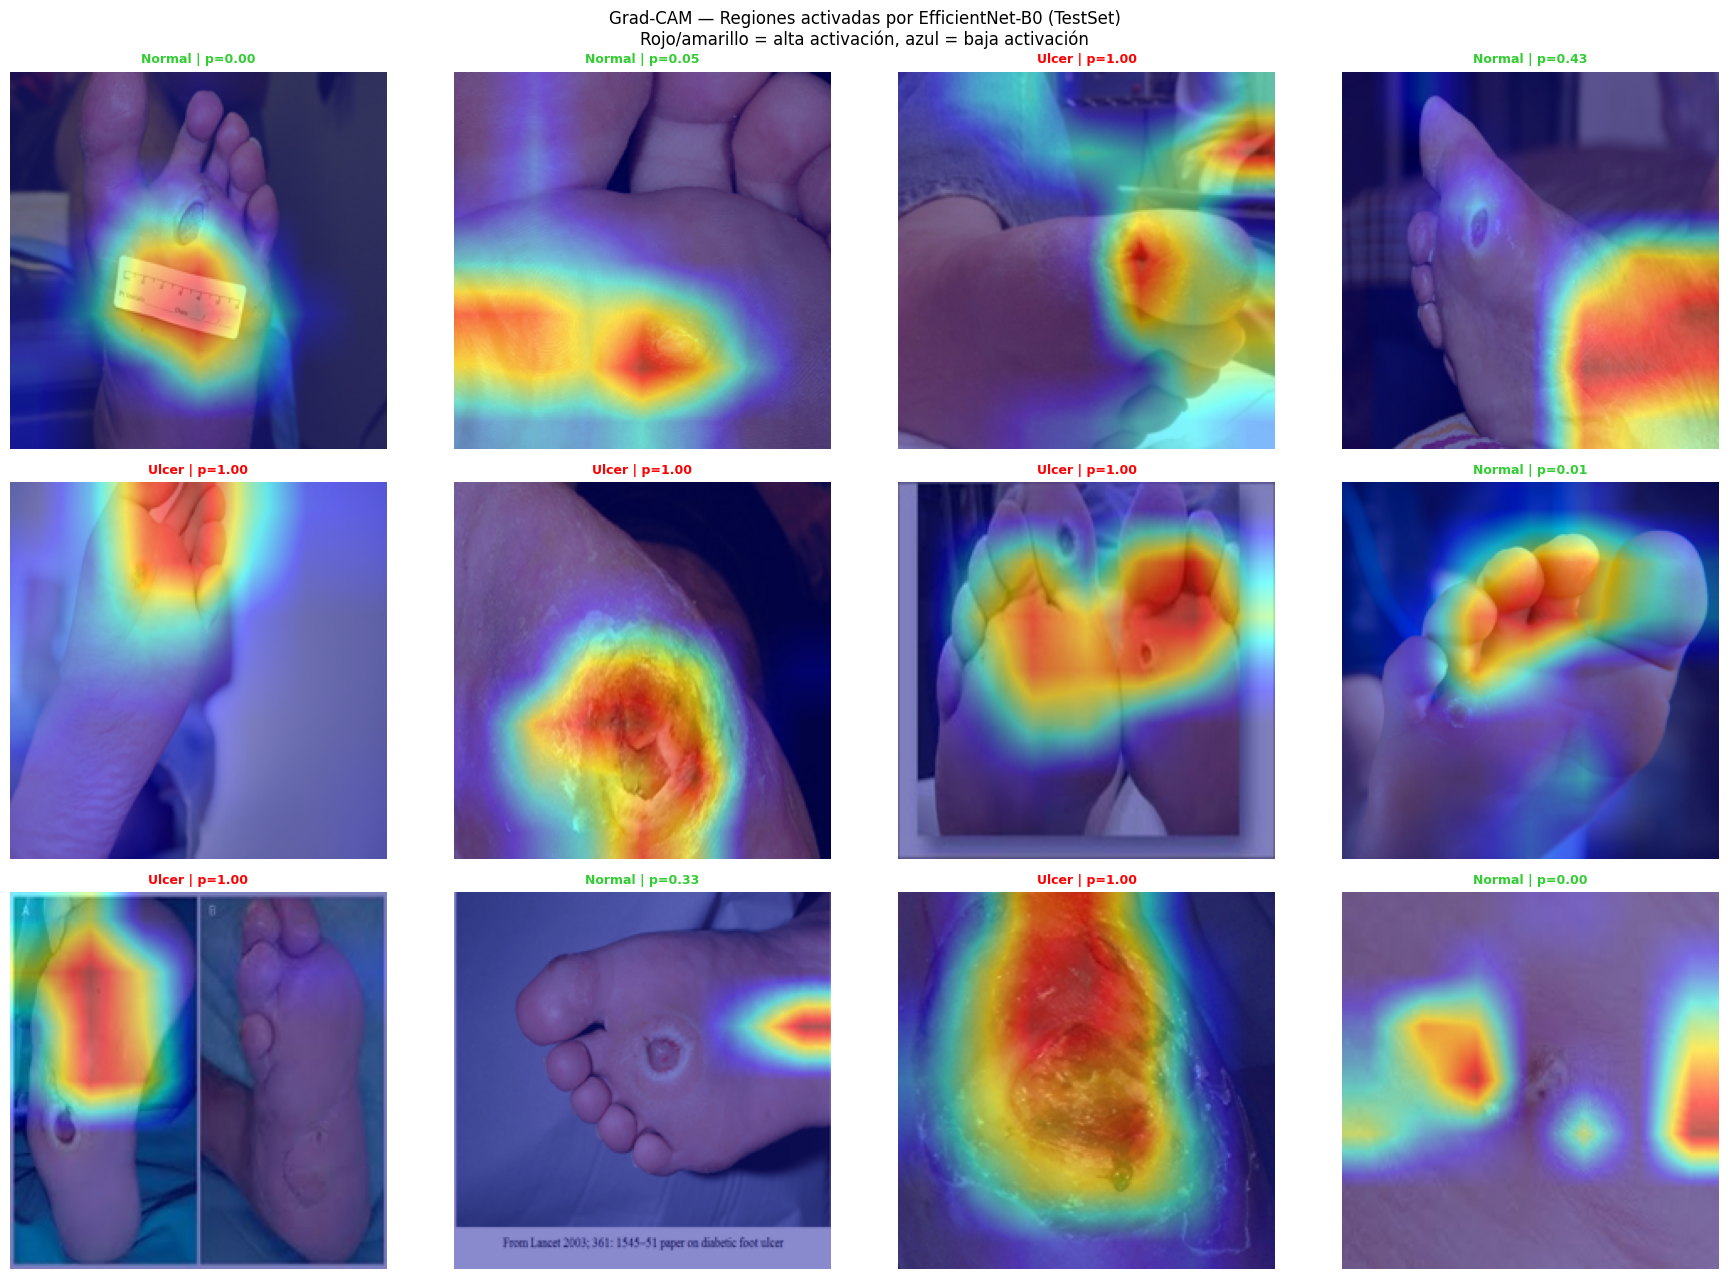

Grad-CAM guardado en /content/gradcam_testset.png


In [18]:
# ── 15. Grad-CAM sobre 12 imágenes del TestSet ───────────────────────────────
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Asegurar que usamos el mejor modelo con gradientes habilitados
model.load_state_dict(torch.load('/content/best_model.pth'))
model.eval()
for p in model.parameters():
    p.requires_grad_(True)

# Último bloque MBConv — produce el mapa espacial más rico antes del GAP
target_layers = [model.blocks[-1]]

# Tomar 12 imágenes: intentar balance entre predicciones
ulcer_sample  = df_pred[df_pred['prediction'] == 'Ulcer'].sample(
                    n=min(6, (df_pred['prediction']=='Ulcer').sum()), random_state=SEED)
normal_sample = df_pred[df_pred['prediction'] == 'Normal'].sample(
                    n=min(6, (df_pred['prediction']=='Normal').sum()), random_state=SEED)
cam_sample = pd.concat([ulcer_sample, normal_sample]).sample(frac=1, random_state=SEED)
cam_sample = cam_sample.head(12)

fig, axes = plt.subplots(3, 4, figsize=(18, 13))

with GradCAM(model=model, target_layers=target_layers) as cam_extractor:
    for ax, (_, row) in zip(axes.flatten(), cam_sample.iterrows()):
        img_path = Path(TEST_DIR) / row['filename']

        # Imagen RGB original redimensionada (float32 en [0,1] para overlay)
        orig_pil = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        orig_np  = np.array(orig_pil, dtype=np.float32) / 255.0

        # Tensor normalizado
        tensor = val_tf(Image.open(img_path).convert('RGB')).unsqueeze(0).to(DEVICE)

        # Target = clase predicha (forzamos la clase que el modelo eligió)
        pred_class = 1 if row['prediction'] == 'Ulcer' else 0
        targets    = [ClassifierOutputTarget(pred_class)]

        grayscale_cam = cam_extractor(input_tensor=tensor, targets=targets)
        grayscale_cam = grayscale_cam[0]  # (H, W) en [0, 1]

        # Overlay heat-map sobre imagen original
        overlay = show_cam_on_image(orig_np, grayscale_cam, use_rgb=True)

        color = 'red' if row['prediction'] == 'Ulcer' else 'limegreen'
        ax.imshow(overlay)
        ax.set_title(
            f"{row['prediction']} | p={row['prob_ulcer']:.2f}",
            color=color, fontsize=9, fontweight='bold'
        )
        ax.axis('off')

plt.suptitle(
    'Grad-CAM — Regiones activadas por EfficientNet-B0 (TestSet)\n'
    'Rojo/amarillo = alta activación, azul = baja activación',
    fontsize=12
)
plt.tight_layout()
plt.savefig('/content/gradcam_testset.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grad-CAM guardado en /content/gradcam_testset.png')

---
## 16 — Exportar a ONNX
Exportamos **dos salidas**:
- `logits` → (B, 2) para clasificación
- `features` → (B, 1280, 7, 7) mapas espaciales para CAM en producción

También guardamos los pesos del clasificador (`classifier_weights.npy`) para reconstruir el CAM en FastAPI sin necesidad de gradientes.

In [22]:
# ── 16. Exportar a ONNX ───────────────────────────────────────────────────────
import onnxruntime as ort

class EfficientNetDualOutput(nn.Module):
    """
    Wrapper que expone dos salidas:
      - logits   : (B, 2)          → para clasificación
      - features : (B, 1280, 7, 7) → mapas espaciales para CAM sin gradientes
    """
    def __init__(self, base_model):
        super().__init__()
        self.base = base_model

    def forward(self, x):
        features = self.base.forward_features(x)    # (B, 1280, 7, 7)
        logits   = self.base.forward_head(features)  # (B, 2)
        return logits, features

# Cargar mejor modelo en CPU para exportar
model.load_state_dict(torch.load('/content/best_model.pth', map_location='cpu'))
model.eval().cpu()

wrapper = EfficientNetDualOutput(model).eval()

dummy    = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
ONNX_PATH = '/content/dfu_efficientnet_b0.onnx'

torch.onnx.export(
    wrapper,
    dummy,
    ONNX_PATH,
    opset_version=17,
    input_names=['image'],
    output_names=['logits', 'features'],
    dynamic_axes={
        'image'   : {0: 'batch_size'},
        'logits'  : {0: 'batch_size'},
        'features': {0: 'batch_size'},
    },
    do_constant_folding=True,
)
print(f'ONNX exportado → {ONNX_PATH}')

# Pesos del clasificador: shape (2, 1280)
# CAM(clase c) = ReLU( sum_k( W[c,k] * features[k, H, W] ) )
classifier_weights = model.classifier.weight.detach().cpu().numpy()
np.save('/content/classifier_weights.npy', classifier_weights)
print(f'Pesos clasificador guardados: shape={classifier_weights.shape}')

# ── Verificación rápida ───────────────────────────────────────────────────────
sess = ort.InferenceSession(ONNX_PATH, providers=['CPUExecutionProvider'])
logits_out, feats_out = sess.run(None, {'image': dummy.numpy()})
print(f'Verificación ONNX OK')
print(f'  logits  : {logits_out.shape}  → esperado (1, 2)')
print(f'  features: {feats_out.shape} → esperado (1, 1280, 7, 7)')

# Volver modelo a DEVICE para siguientes celdas
model.to(DEVICE)

W0823 23:48:52.012000 9797 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `EfficientNetDualOutput([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EfficientNetDualOutput([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
        func=_partial_convert_version, model=model
    )
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        proto, target_version=self.target_version
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
RuntimeError: /project/onnx/version_converter/adapters/axes_input_to_attribute.h:56: 

[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
ONNX exportado → /content/dfu_efficientnet_b0.onnx
Pesos clasificador guardados: shape=(2, 1280)
Verificación ONNX OK
  logits  : (1, 2)  → esperado (1, 2)
  features: (1, 1280, 7, 7) → esperado (1, 1280, 7, 7)


EfficientNet(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2

In [23]:
# ── 17. Copiar todos los outputs a Drive ──────────────────────────────────────
import shutil

OUT_DIR = os.path.join(BASE_DIR, 'outputs')
os.makedirs(OUT_DIR, exist_ok=True)

outputs = [
    'best_model.pth',
    'training_curves.png',
    'confusion_matrix.png',
    'roc_curve.png',
    'testset_predictions.csv',
    'testset_sample.png',
    'gradcam_testset.png',          # ← nuevo
    'dfu_efficientnet_b0.onnx',     # ← nuevo
    'classifier_weights.npy',       # ← nuevo
]

for fname in outputs:
    src = f'/content/{fname}'
    if os.path.exists(src):
        shutil.copy(src, os.path.join(OUT_DIR, fname))
        size_mb = os.path.getsize(src) / 1e6
        print(f'Copiado → Drive/DFU/outputs/{fname}  ({size_mb:.1f} MB)')
    else:
        print(f'No encontrado: {fname}')

print('\n✓ Todo guardado en Google Drive.')

Copiado → Drive/DFU/outputs/best_model.pth  (16.3 MB)
Copiado → Drive/DFU/outputs/training_curves.png  (0.1 MB)
Copiado → Drive/DFU/outputs/confusion_matrix.png  (0.0 MB)
Copiado → Drive/DFU/outputs/roc_curve.png  (0.0 MB)
Copiado → Drive/DFU/outputs/testset_predictions.csv  (0.0 MB)
Copiado → Drive/DFU/outputs/testset_sample.png  (2.9 MB)
Copiado → Drive/DFU/outputs/gradcam_testset.png  (3.0 MB)
Copiado → Drive/DFU/outputs/dfu_efficientnet_b0.onnx  (0.5 MB)
Copiado → Drive/DFU/outputs/classifier_weights.npy  (0.0 MB)

✓ Todo guardado en Google Drive.


In [24]:
import pandas as pd
df = pd.read_csv('/content/testset_predictions.csv')
print(df.head(10))
print(f'\nTotal predicciones: {len(df)}')
print(df['predicted_label'].value_counts())

            filename prediction  prob_normal  prob_ulcer
0              0.jpg      Ulcer       0.0823      0.9177
1  0cbt67mm0fr01.jpg      Ulcer       0.0001      0.9999
2             1 .jpg      Ulcer       0.0000      1.0000
3              1.jpg     Normal       0.5650      0.4350
4             10.jpg      Ulcer       0.3238      0.6762
5             11.jpg      Ulcer       0.0000      1.0000
6       1167 (1).jpg      Ulcer       0.0001      0.9999
7           1167.jpg      Ulcer       0.0000      1.0000
8             12.jpg     Normal       0.7912      0.2088
9             13.jpg      Ulcer       0.0002      0.9998

Total predicciones: 167


KeyError: 'predicted_label'

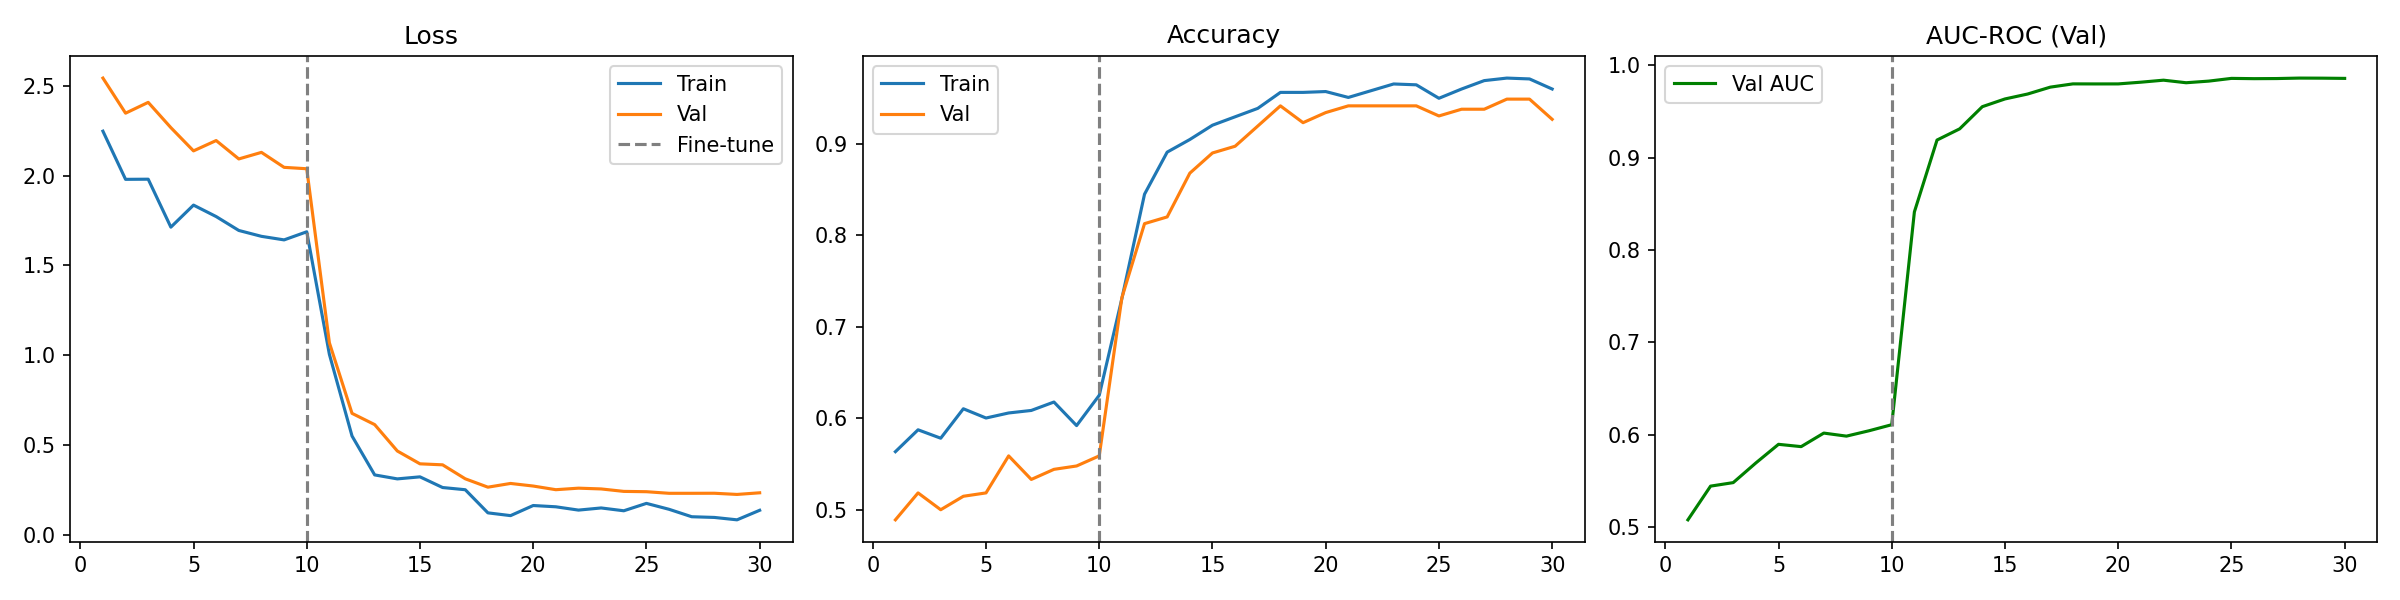

In [26]:
# Ver las métricas de validación del mejor modelo
import json, os

# Intentar leer el log de entrenamiento si existe
log_path = '/content/training_log.json'
if os.path.exists(log_path):
    with open(log_path) as f:
        print(json.load(f))
else:
    # Ver las curvas de entrenamiento guardadas
    from IPython.display import Image
    display(Image('/content/training_curves.png'))